# Notebook 3: Khởi tạo **AFK-MC2** và phân cụm **K-means**

## Đọc nhanh kết quả Notebook 2 (AIC / BIC & PCA)

**Biểu đồ AIC / BIC theo K (GMM)**  
- Cả AIC và BIC **giảm mạnh** khi tăng số thành phần — mô hình khớp dữ liệu hơn nhưng phức tạp hơn.  
- Có **khúc gập rõ** khoảng **K = 3 → 4** và **K = 5 → 6**: sau đó độ giảm **chậm dần** (kiểu “elbow”).  
- Trong dải bạn vẽ, BIC thường **thấp nhất** về phía **K lớn** (ví dụ 10–12); tại **K = 11** có nhích **lên** một chút so với K = 10 — gợi ý thêm thành phần không còn “đáng” với mức phạt BIC.  

**Ý cho đề tài:** số thành phần **GMM** (mô hình hỗn hợp) **không bắt buộc** trùng số cụm **K-means** dùng cho phân khúc khách. Thường chọn **K cụm marketing nhỏ hơn** (4–6) để dễ diễn giải, dù BIC GMM thích K lớn hơn.

**Biểu đồ PCA–2D (nhãn GMM)**  
- Hai PC giải thích phần lớn phương sai → hình chiếu **đại diện tốt** cho RFM đã chuẩn hóa.  
- Có **chùm tách khá rõ** (ví dụ một dải gần tuyến tính) và vùng **chồng lấn ở giữa** — bình thường với dữ liệu thật và với nhiều thành phần GMM.

---

## Pipeline **đúng tinh thần paper** (GMS → AFK-MC2 trên tập con → K-means full)

Trong bài gốc, thứ tự là:

1. **Gms:** học **GMM** trên toàn bộ dữ liệu, **sinh mẫu** từ GMM, rồi với mỗi mẫu tìm **điểm thật gần nhất** trong tập gốc → được **tập con** `DS_sample`.  
2. **AFK-MC2** chạy trên **`DS_sample`** để có bộ tâm khởi tạo tốt.  
3. Bước cuối trên **toàn bộ dữ liệu**: paper gọi tiếp một lần **AFK-MC2** với tâm đã có; package Python `afkmc2` **chỉ** có hàm `afkmc2(X, k)` **không** nhận tâm sẵn cho lần hai.  
4. **Cách làm tương đương thực tế (đã ghi trong báo cáo):** dùng **K-means (Elkan)** trên **toàn bộ `X`** với `init=` đúng **k tâm** vừa tính từ AFK-MC2 trên tập con — tức **tinh chỉnh Lloyd** từ seed paper-style.

Ngoài ra notebook vẫn giữ baseline **AFK-MC2 trực tiếp trên full `X`** để so sánh với pipeline trên.

## Mục tiêu Notebook 3

1. Cài **Gms** (lấy mẫu + map về điểm thật) và **AFK-MC2 trên tập con** → **K-means full**.  
2. So sánh với **AFK-MC2 trên full**, **K-means++**, **random init** (SSE, Silhouette, Davies–Bouldin).  
3. Lưu nhãn cụm cho bước phân tích RFM.

**Cài đặt:** `python3 -m pip install -r requirements.txt` (cần `afkmc2`; GMM dùng `sklearn`).

## Chọn K cho K-means

Ngay sau khi có ma trận `X`, notebook **quét** các giá trị `k` trong `[K_SEARCH_MIN, K_SEARCH_MAX]`: mỗi `k` chạy K-means++ (`n_init=10`), ghi **SSE (inertia)**, **Silhouette**, **Davies–Bouldin**, **n_iter** vào `data/kmeans_k_selection.csv` (hoặc `data_customer/...`), đồng thời vẽ đồ thị elbow và silhouette/DBI. `N_CLUSTERS` dùng cho GMS / AFK-MC2 / so sánh baseline được gán sau bước này: mặc định **`K_SELECTION_MODE = "fixed"`** và **`FIXED_K = 4`**; có thể đổi sang `"auto_silhouette"` hoặc `"auto_davies_bouldin"`.

In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture

try:
    import afkmc2.afkmc2 as afk_seed
except ImportError as e:
    raise ImportError(
        "Cần cài afkmc2: python3 -m pip install afkmc2"
    ) from e

def _project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "requirements.txt").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return Path.cwd().resolve()


ROOT = _project_root()
DATA_PATH = ROOT / "data" / "rfm_customers.csv"
OUT_DIR = ROOT / "data"
MODEL_PATH = ROOT / "models" / "gmm_rfm.joblib"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["R_z", "F_z", "M_z"]
RANDOM_STATE = 42

# --- Chọn số cụm K cho K-means (KHÁC số thành phần GMM ở NB2)
# Quét k → lưu CSV + vẽ đồ thị; sau đó gán N_CLUSTERS ở cell tiếp theo.
#   "fixed": dùng FIXED_K (mặc định 4 — paper / báo cáo), vẫn có bảng số đối chiếu.
#   "auto_silhouette": k có Silhouette cao nhất (trong khoảng quét).
#   "auto_davies_bouldin": k có Davies–Bouldin thấp nhất.
K_SEARCH_MIN = 2
K_SEARCH_MAX = 10
K_SELECTION_MODE = "fixed"  # "fixed" | "auto_silhouette" | "auto_davies_bouldin"
FIXED_K = 4

# --- GMS (giống paper): tỷ lệ lấy mẫu trên n khách
SAMPLE_RATE = 0.5

# Trọng số từng chiều khi tìm điểm thật gần nhất (paper: ω). [1,1,1] = Euclidean thông thường trên (R_z,F_z,M_z)
OMEGA = np.ones(len(FEATURE_COLS), dtype=float)

# GMM cho GMS: ưu tiên load `models/gmm_rfm.joblib` từ NB2; không có thì fit mới
GMM_FALLBACK_N_COMPONENTS = 8
GMM_N_INIT = 5
GMM_MAX_ITER = 200
GMM_REG_COVAR = 1e-3

AFKMC2_CHAIN_LEN = 200
KMEANS_MAX_ITER = 300

X shape: (5878, 3)


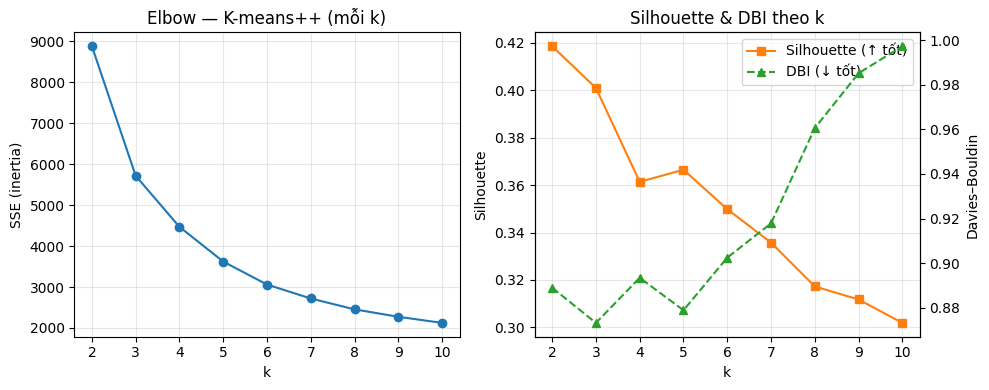


=== Bảng quét k (K-means++, n_init=10) ===
  k  SSE_inertia  silhouette  davies_bouldin  n_iter
 2  8879.753864    0.418630        0.888986       4
 3  5715.503664    0.401026        0.873209       7
 4  4469.006535    0.361398        0.893440      16
 5  3621.429999    0.366502        0.878871      22
 6  3060.503972    0.349856        0.902456      21
 7  2720.481339    0.335744        0.917814      39
 8  2454.747346    0.317264        0.960575      34
 9  2273.723060    0.311744        0.985152      19
10  2124.516865    0.301865        0.997259      21

→ N_CLUSTERS = 4
   Cơ sở: MODE="fixed", FIXED_K=4 (paper / báo cáo; bảng trên để đối chiếu)
   Đã lưu: /Users/kotori/GMS_AFKMC2/data/kmeans_k_selection.csv


In [2]:
rfm = pd.read_csv(DATA_PATH)
missing = [c for c in FEATURE_COLS if c not in rfm.columns]
if missing:
    raise ValueError(f"Thiếu cột {missing}. Chạy 01_DataProcessing.ipynb trước.")

X = rfm[FEATURE_COLS].to_numpy(dtype=float)
ids = rfm["customer_id"].to_numpy()
print("X shape:", X.shape)

# ---- Quét k: bảng số + CSV + đồ thị (cơ sở định lượng cho việc chọn K-means)
k_max_eff = min(K_SEARCH_MAX, X.shape[0] - 1)
if k_max_eff < K_SEARCH_MIN:
    raise ValueError(f"Cần n > k: n={X.shape[0]}, K_SEARCH_MIN={K_SEARCH_MIN}")

_rows = []
for _k in range(K_SEARCH_MIN, k_max_eff + 1):
    _km = KMeans(
        n_clusters=_k,
        init="k-means++",
        n_init=10,
        max_iter=KMEANS_MAX_ITER,
        random_state=RANDOM_STATE,
        algorithm="elkan",
    )
    _lab = _km.fit_predict(X)
    _rows.append(
        {
            "k": _k,
            "SSE_inertia": _km.inertia_,
            "silhouette": silhouette_score(X, _lab),
            "davies_bouldin": davies_bouldin_score(X, _lab),
            "n_iter": _km.n_iter_,
        }
    )
k_scan = pd.DataFrame(_rows)
k_scan_path = OUT_DIR / "kmeans_k_selection.csv"
k_scan.to_csv(k_scan_path, index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(k_scan["k"], k_scan["SSE_inertia"], "o-", color="C0")
axes[0].set_xlabel("k")
axes[0].set_ylabel("SSE (inertia)")
axes[0].set_title("Elbow — K-means++ (mỗi k)")
axes[0].grid(True, alpha=0.3)
axes[1].plot(k_scan["k"], k_scan["silhouette"], "s-", color="C1", label="Silhouette (↑ tốt)")
ax1b = axes[1].twinx()
ax1b.plot(k_scan["k"], k_scan["davies_bouldin"], "^--", color="C2", label="DBI (↓ tốt)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
ax1b.set_ylabel("Davies–Bouldin")
axes[1].set_title("Silhouette & DBI theo k")
axes[1].grid(True, alpha=0.3)
lines1, lab1 = axes[1].get_legend_handles_labels()
lines2, lab2 = ax1b.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, lab1 + lab2, loc="best")
plt.tight_layout()
plt.show()

if K_SELECTION_MODE == "fixed":
    if not (K_SEARCH_MIN <= FIXED_K <= k_max_eff):
        raise ValueError(f"FIXED_K={FIXED_K} phải nằm trong [{K_SEARCH_MIN}, {k_max_eff}]")
    N_CLUSTERS = int(FIXED_K)
    _why = f'MODE="fixed", FIXED_K={FIXED_K} (paper / báo cáo; bảng trên để đối chiếu)'
elif K_SELECTION_MODE == "auto_silhouette":
    _best = k_scan.loc[k_scan["silhouette"].idxmax()]
    N_CLUSTERS = int(_best["k"])
    _why = f'MODE="auto_silhouette" → k={N_CLUSTERS} (Silhouette={_best["silhouette"]:.6f}, max trong [{K_SEARCH_MIN}, {k_max_eff}])'
elif K_SELECTION_MODE == "auto_davies_bouldin":
    _best = k_scan.loc[k_scan["davies_bouldin"].idxmin()]
    N_CLUSTERS = int(_best["k"])
    _why = f'MODE="auto_davies_bouldin" → k={N_CLUSTERS} (DBI={_best["davies_bouldin"]:.6f}, min trong [{K_SEARCH_MIN}, {k_max_eff}])'
else:
    raise ValueError('K_SELECTION_MODE phải là "fixed" | "auto_silhouette" | "auto_davies_bouldin"')

print("\n=== Bảng quét k (K-means++, n_init=10) ===\n", k_scan.to_string(index=False))
print(f"\n→ N_CLUSTERS = {N_CLUSTERS}\n   Cơ sở: {_why}\n   Đã lưu: {k_scan_path.resolve()}")

GMS: n_sample=2939 (rate≈0.5), X_sub shape=(2939, 3)
GMM cho GMS: n_components=8 | synth_gms shape=(2939, 3)
Mẫu 5 điểm sinh từ GMM (cùng không gian R_z, F_z, M_z):
      R_z       F_z       M_z
-1.091631  0.067878 -0.189097
-0.829591 -0.179497  0.264037
-0.886987 -0.347245  0.468923
-0.631200  0.090164  0.055000
-0.607046  0.057217  0.237254


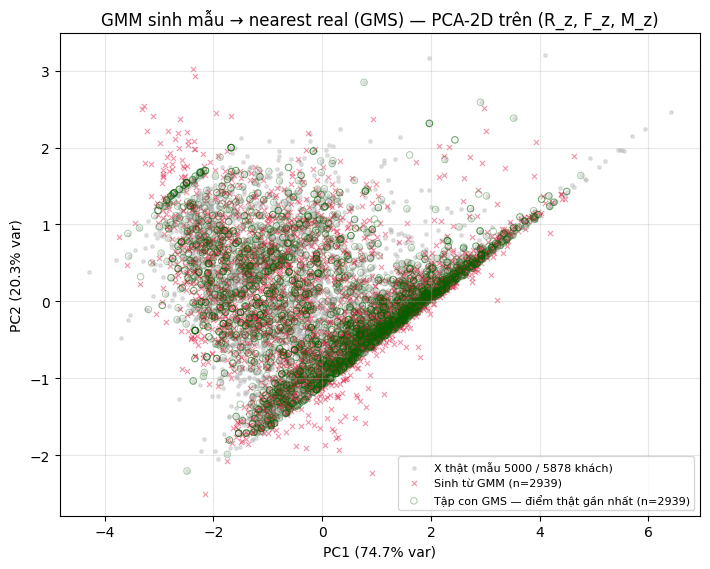

Pipeline GMS + AFK-MC2(sub) + K-means(full) — SSE: 4468.914716253313 | n_iter: 6
Baseline AFK-MC2(full) + K-means — SSE: 4785.251991296289 | n_iter: 16


In [3]:
np.random.seed(RANDOM_STATE)


def gms_nearest_real_points(
    X_data: np.ndarray,
    gmm: GaussianMixture,
    n_sample: int,
    omega: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Gms: sinh n_sample điểm từ GMM; map mỗi điểm → hàng trong X_data gần nhất (khoảng cách có trọng số omega).
    Trả về (X_sub, synth): `synth` là batch từ `gmm.sample` (để xem / vẽ)."""
    synth, _ = gmm.sample(n_sample)
    omega = np.asarray(omega, dtype=float).reshape(1, -1)
    idx = []
    for s in synth:
        diff = X_data - s
        dist = np.linalg.norm(diff * omega, axis=1)
        idx.append(int(np.argmin(dist)))
    return X_data[np.array(idx, dtype=int)], synth


def load_or_fit_gmm_for_gms(X_data: np.ndarray) -> GaussianMixture:
    if MODEL_PATH.is_file():
        bundle = joblib.load(MODEL_PATH)
        gmm = bundle["gmm"]
        return gmm
    gmm = GaussianMixture(
        n_components=GMM_FALLBACK_N_COMPONENTS,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=GMM_N_INIT,
        max_iter=GMM_MAX_ITER,
        reg_covar=GMM_REG_COVAR,
    )
    gmm.fit(X_data)
    return gmm


n = X.shape[0]
n_sample = max(N_CLUSTERS, int(round(SAMPLE_RATE * n)))
gmm_gms = load_or_fit_gmm_for_gms(X)
X_sub, synth_gms = gms_nearest_real_points(X, gmm_gms, n_sample, OMEGA)
print(f"GMS: n_sample={n_sample} (rate≈{SAMPLE_RATE}), X_sub shape={X_sub.shape}")
print(
    f"GMM cho GMS: n_components={gmm_gms.n_components} | synth_gms shape={synth_gms.shape}"
)
print("Mẫu 5 điểm sinh từ GMM (cùng không gian R_z, F_z, M_z):")
print(pd.DataFrame(synth_gms[:5], columns=FEATURE_COLS).to_string(index=False))

# --- Trực quan: điểm từ GMM.sample vs dữ liệu thật vs tập con sau ánh xạ GMS (PCA-2D)
_rng = np.random.default_rng(RANDOM_STATE)
_bg_n = min(5000, X.shape[0])
_bg_idx = _rng.choice(X.shape[0], size=_bg_n, replace=False)
_viz_n = synth_gms.shape[0]
_pca_gms = PCA(n_components=2, random_state=RANDOM_STATE)
_X_pca = _pca_gms.fit_transform(X)
_synth2 = _pca_gms.transform(synth_gms)
_Xsub2 = _pca_gms.transform(X_sub)

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.scatter(
    _X_pca[_bg_idx, 0],
    _X_pca[_bg_idx, 1],
    s=6,
    c="#b0b0b0",
    alpha=0.35,
    label=f"X thật (mẫu {_bg_n} / {X.shape[0]} khách)",
)
ax.scatter(
    _synth2[:, 0],
    _synth2[:, 1],
    s=14,
    c="crimson",
    alpha=0.45,
    marker="x",
    linewidths=0.8,
    label=f"Sinh từ GMM (n={_viz_n})",
)
ax.scatter(
    _Xsub2[:, 0],
    _Xsub2[:, 1],
    s=22,
    facecolors="none",
    edgecolors="darkgreen",
    linewidths=0.7,
    alpha=0.35,
    label=f"Tập con GMS — điểm thật gần nhất (n={_viz_n})",
)
ax.set_xlabel(f"PC1 ({_pca_gms.explained_variance_ratio_[0] * 100:.1f}% var)")
ax.set_ylabel(f"PC2 ({_pca_gms.explained_variance_ratio_[1] * 100:.1f}% var)")
ax.set_title("GMM sinh mẫu → nearest real (GMS) — PCA-2D trên (R_z, F_z, M_z)")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Pipeline paper-style: AFK-MC2 chỉ trên tập con → seed cho K-means full
init_from_sub = afk_seed.afkmc2(X_sub, N_CLUSTERS, m=AFKMC2_CHAIN_LEN)
km_paper = KMeans(
    n_clusters=N_CLUSTERS,
    init=init_from_sub,
    n_init=1,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
)
km_paper.fit(X)
print("Pipeline GMS + AFK-MC2(sub) + K-means(full) — SSE:", km_paper.inertia_, "| n_iter:", km_paper.n_iter_)

# --- Baseline: AFK-MC2 trực tiếp trên toàn bộ X (không qua GMS / tập con)
init_full = afk_seed.afkmc2(X, N_CLUSTERS, m=AFKMC2_CHAIN_LEN)
km_afk_full = KMeans(
    n_clusters=N_CLUSTERS,
    init=init_full,
    n_init=1,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
)
km_afk_full.fit(X)
print("Baseline AFK-MC2(full) + K-means — SSE:", km_afk_full.inertia_, "| n_iter:", km_afk_full.n_iter_)

In [4]:
km_pp = KMeans(
    n_clusters=N_CLUSTERS,
    init="k-means++",
    n_init=10,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
)
km_pp.fit(X)

km_rand = KMeans(
    n_clusters=N_CLUSTERS,
    init="random",
    n_init=10,
    max_iter=KMEANS_MAX_ITER,
    random_state=RANDOM_STATE,
    algorithm="elkan",
)
km_rand.fit(X)

print("K-means++ inertia:", km_pp.inertia_)
print("K-means random inertia:", km_rand.inertia_)

K-means++ inertia: 4469.006535448559
K-means random inertia: 4468.96110632747


In [5]:
def metrics_for_model(name: str, model: KMeans) -> dict:
    """SSE (trong sklearn) = inertia = tổng bình phương khoảng cách tới tâm cụm được gán."""
    lab = model.labels_
    return {
        "method": name,
        "SSE_inertia": float(model.inertia_),
        "silhouette": float(silhouette_score(X, lab)),
        "davies_bouldin": float(davies_bouldin_score(X, lab)),
        "n_iter": int(model.n_iter_),
    }


rows = [
    metrics_for_model("GMS + AFK-MC2 (sub) + K-means (full)", km_paper),
    metrics_for_model("AFK-MC2 (full) + K-means", km_afk_full),
    metrics_for_model("K-means++", km_pp),
    metrics_for_model("K-means (random init)", km_rand),
]
metrics_df = pd.DataFrame(rows)
metrics_df

,method,SSE_inertia,silhouette,davies_bouldin,n_iter
0,GMS + AFK-MC2 (sub) + K-means (full),4468.914716,0.361583,0.891984,6
1,AFK-MC2 (full) + K-means,4785.251991,0.384365,0.927945,16
2,K-means++,4469.006535,0.361398,0.893440,16
3,K-means (random init),4468.961106,0.361472,0.892792,12


In [6]:
# Gộp nhãn cụm (chính: AFK-MC2 + K-means) vào bảng RFM gốc để phân tích sau
out = rfm.copy()
out["kmeans_gms_afkmc2_pipeline"] = km_paper.labels_
out["kmeans_afkmc2_full"] = km_afk_full.labels_
out["kmeans_pp"] = km_pp.labels_
out["kmeans_random"] = km_rand.labels_

out_path = OUT_DIR / "rfm_with_kmeans_clusters.csv"
out.to_csv(out_path, index=False)
print("Đã lưu:", out_path.resolve())

metrics_path = OUT_DIR / "kmeans_init_comparison.csv"
metrics_df.to_csv(metrics_path, index=False)
print("Đã lưu:", metrics_path.resolve())
out.head()

Đã lưu: /Users/kotori/GMS_AFKMC2/data/rfm_with_kmeans_clusters.csv
Đã lưu: /Users/kotori/GMS_AFKMC2/data/kmeans_init_comparison.csv


,customer_id,R,F,M,F_log1p,M_log1p,R_z,F_z,M_z,kmeans_gms_afkmc2_pipeline,kmeans_afkmc2_full,kmeans_pp,kmeans_random
0,12346.0,325,12,77556.46,2.564949,11.258774,0.595584,1.254496,3.186625,3,0,3,3
1,12347.0,1,8,5633.32,2.197225,8.636632,-0.952279,0.800166,1.297127,3,0,3,3
2,12348.0,74,5,2019.40,1.791759,7.611051,-0.603532,0.299207,0.558100,1,3,2,0
3,12349.0,18,4,4428.69,1.609438,8.396085,-0.871064,0.073946,1.123790,1,0,2,0
4,12350.0,309,1,334.40,0.693147,5.815324,0.519146,-1.058146,-0.735888,2,2,0,1


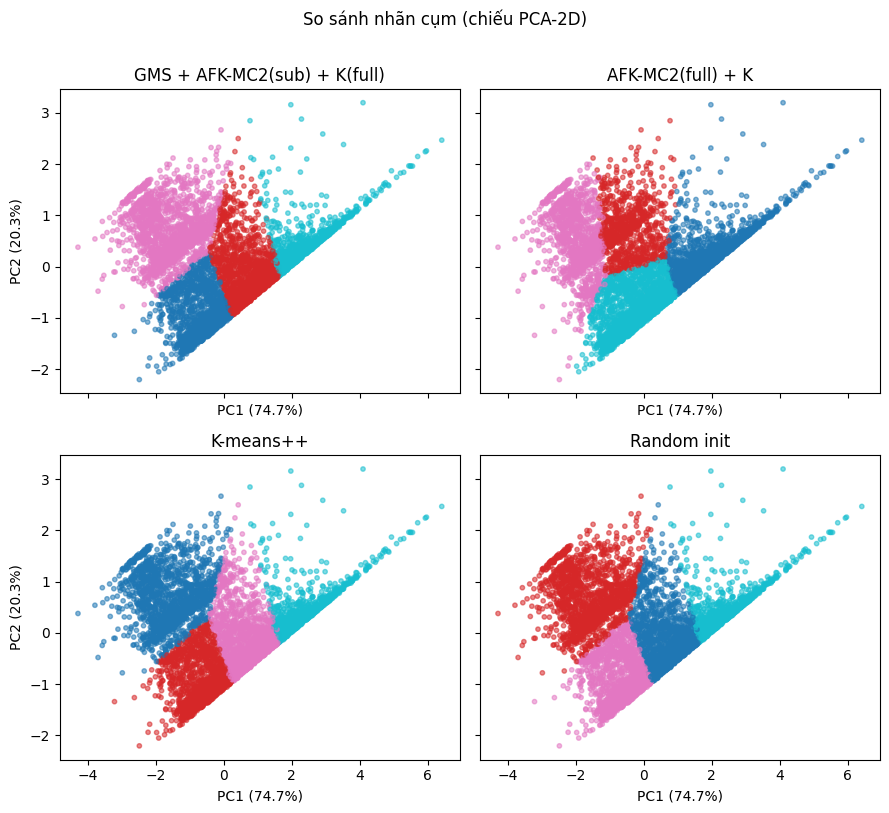

In [7]:
# So sánh trực quan (PCA-2D)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
axes = axes.ravel()
titles_labels = [
    ("GMS + AFK-MC2(sub) + K(full)", km_paper.labels_),
    ("AFK-MC2(full) + K", km_afk_full.labels_),
    ("K-means++", km_pp.labels_),
    ("Random init", km_rand.labels_),
]
for ax, (title, lab) in zip(axes, titles_labels):
    ax.scatter(X2[:, 0], X2[:, 1], c=lab, cmap="tab10", s=10, alpha=0.55)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.suptitle("So sánh nhãn cụm (chiếu PCA-2D)", y=1.01)
plt.tight_layout()
plt.show()